**Predicting Student Depression from Behavioral Data**

**Problem**: “Binary classification: depressed vs not”

**Data**: Kaggle Synthetic Dataset (18 Features, 27901 entries)

**Metrics**: Accuracy, AUC, Charts

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv('Student_Depression_Dataset.csv')

In [3]:
df.head() 


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


**Cleaning**

In [4]:
#replace id values with 0
df['id'] = np.arange(len(df))

In [5]:
#change CGPA scale from 0-10 to 0-4
def cgpa_scale(x):
    return (x / 10) * 4
    
df['CGPA'] = df['CGPA'].apply(cgpa_scale)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

In [7]:
#proportion of students with depression
df['Depression'].value_counts(normalize=True)

Depression
1    0.585499
0    0.414501
Name: proportion, dtype: float64

In [8]:
df.groupby('Financial Stress')['Depression'].mean()

Financial Stress
1.0    0.318688
2.0    0.429757
3.0    0.589361
4.0    0.690909
5.0    0.812807
Name: Depression, dtype: float64

In [9]:
df.groupby('Degree')['Depression'].mean()

Degree
B.Arch      0.589310
B.Com       0.566401
B.Ed        0.546867
B.Pharm     0.528395
B.Tech      0.568576
BA          0.535000
BBA         0.584770
BCA         0.571528
BE          0.544861
BHM         0.550270
BSc         0.588964
Class 12    0.707730
LLB         0.530551
LLM         0.537344
M.Com       0.531335
M.Ed        0.505481
M.Pharm     0.539519
M.Tech      0.509785
MA          0.533088
MBA         0.539146
MBBS        0.580460
MCA         0.535441
MD          0.520979
ME          0.529730
MHM         0.518325
MSc         0.570588
Others      0.600000
PhD         0.547893
Name: Depression, dtype: float64

In [10]:
#count of degree
df['Degree'].value_counts()

Degree
Class 12    6080
B.Ed        1867
B.Com       1506
B.Arch      1478
BCA         1433
MSc         1190
B.Tech      1152
MCA         1044
M.Tech      1022
BHM          925
BSc          888
M.Ed         821
B.Pharm      810
M.Com        734
MBBS         696
BBA          696
LLB          671
BE           613
BA           600
M.Pharm      582
MD           572
MBA          562
MA           544
PhD          522
LLM          482
MHM          191
ME           185
Others        35
Name: count, dtype: int64

In [11]:
#convert categorical column to string type
df['Gender'] = df['Gender'].astype(str)
#replace the values
df['Gender'] = df['Gender'].replace({'Male': 0, 'Female': 1})

/var/folders/6q/z403kbqn59qg1mpwf8xqml5r0000gn/T/ipykernel_72510/2553939375.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Gender'] = df['Gender'].replace({'Male': 0, 'Female': 1})


In [12]:
#convert dietary habits from 'other', 'healthy' 'moderate', 'unhealthy' to 0,1,2,3
df['Dietary Habits'] = df['Dietary Habits'].astype(str)
df['Dietary Habits'] = df['Dietary Habits'].replace({'Unhealthy': 0, 'Moderate': 1, 'Healthy': 2, 'Others': 3})

/var/folders/6q/z403kbqn59qg1mpwf8xqml5r0000gn/T/ipykernel_72510/1751154697.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Dietary Habits'] = df['Dietary Habits'].replace({'Unhealthy': 0, 'Moderate': 1, 'Healthy': 2, 'Others': 3})


In [13]:
#convert Sleep Duration from 'less than 5 hours', '7-8 hours', '5-6 hours', 'more than 8 hours', 'Others' to 0,1,2,3,4
df['Sleep Duration'] = df['Sleep Duration'].astype(str)
df['Sleep Duration'] = df['Sleep Duration'].replace({'Less than 5 hours': 0, '5-6 hours': 1, '7-8 hours': 2, 'More than 8 hours': 3, 'Others': 4})

/var/folders/6q/z403kbqn59qg1mpwf8xqml5r0000gn/T/ipykernel_72510/1095037266.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Sleep Duration'] = df['Sleep Duration'].replace({'Less than 5 hours': 0, '5-6 hours': 1, '7-8 hours': 2, 'More than 8 hours': 3, 'Others': 4})


In [14]:
#rename 'Have you ever had suicidal thoughts ?' to 'Suicidal Thoughts'
df.rename(columns={'Have you ever had suicidal thoughts ?': 'Suicidal Thoughts'}, inplace=True) 

#convert 'Suicidal Thoughts' from 'yes', 'no' to 0, 1
df['Suicidal Thoughts'] = df['Suicidal Thoughts'].astype(str)
df['Suicidal Thoughts'] = df['Suicidal Thoughts'].replace({'No': 0, 'Yes': 1})

/var/folders/6q/z403kbqn59qg1mpwf8xqml5r0000gn/T/ipykernel_72510/2079815982.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Suicidal Thoughts'] = df['Suicidal Thoughts'].replace({'No': 0, 'Yes': 1})


In [15]:
#rename 'Family History of Mental Illness' to 'Family History'
df.rename(columns={'Family History of Mental Illness': 'Family History'}, inplace=True)

#convert 'Family History' from 'yes', 'no' to 0, 1
df['Family History'] = df['Family History'].astype(str)
df['Family History'] = df['Family History'].replace({'No': 0, 'Yes': 1})

/var/folders/6q/z403kbqn59qg1mpwf8xqml5r0000gn/T/ipykernel_72510/909820077.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Family History'] = df['Family History'].replace({'No': 0, 'Yes': 1})


In [16]:
#values of 'Degree'
df['Degree'].value_counts()

Degree
Class 12    6080
B.Ed        1867
B.Com       1506
B.Arch      1478
BCA         1433
MSc         1190
B.Tech      1152
MCA         1044
M.Tech      1022
BHM          925
BSc          888
M.Ed         821
B.Pharm      810
M.Com        734
MBBS         696
BBA          696
LLB          671
BE           613
BA           600
M.Pharm      582
MD           572
MBA          562
MA           544
PhD          522
LLM          482
MHM          191
ME           185
Others        35
Name: count, dtype: int64

In [17]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Degree'] = le.fit_transform(df['Degree'])
le = LabelEncoder()
df['City'] = le.fit_transform(df['City'])

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
#splitting the data into training and testing sets
x = df[['Age', 'Gender', 'Financial Stress', 'CGPA', 'Dietary Habits', 'Sleep Duration', 'Academic Pressure', 'Study Satisfaction', 'Work/Study Hours', 'Family History', 'Suicidal Thoughts', 'City', 'Degree']]
y = df['Depression']


x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=6)

In [20]:
from sklearn.dummy import DummyClassifier

In [21]:
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(x_train, y_train)
print(f"Baseline Accuracy: {dummy.score(x_test, y_test):.4f}")

Baseline Accuracy: 0.5925


In [22]:
from sklearn.ensemble import RandomForestClassifier

In [23]:
model = RandomForestClassifier(n_estimators=100, random_state=6)
model.fit(x_train, y_train)

#feature importance
importances = model.feature_importances_
feature_names = x_train.columns

#Vizualization 
feature_importance_df = pd.DataFrame({
	'Feature': feature_names, 
	'Importance': importances
}).sort_values(by='Importance', ascending=False)

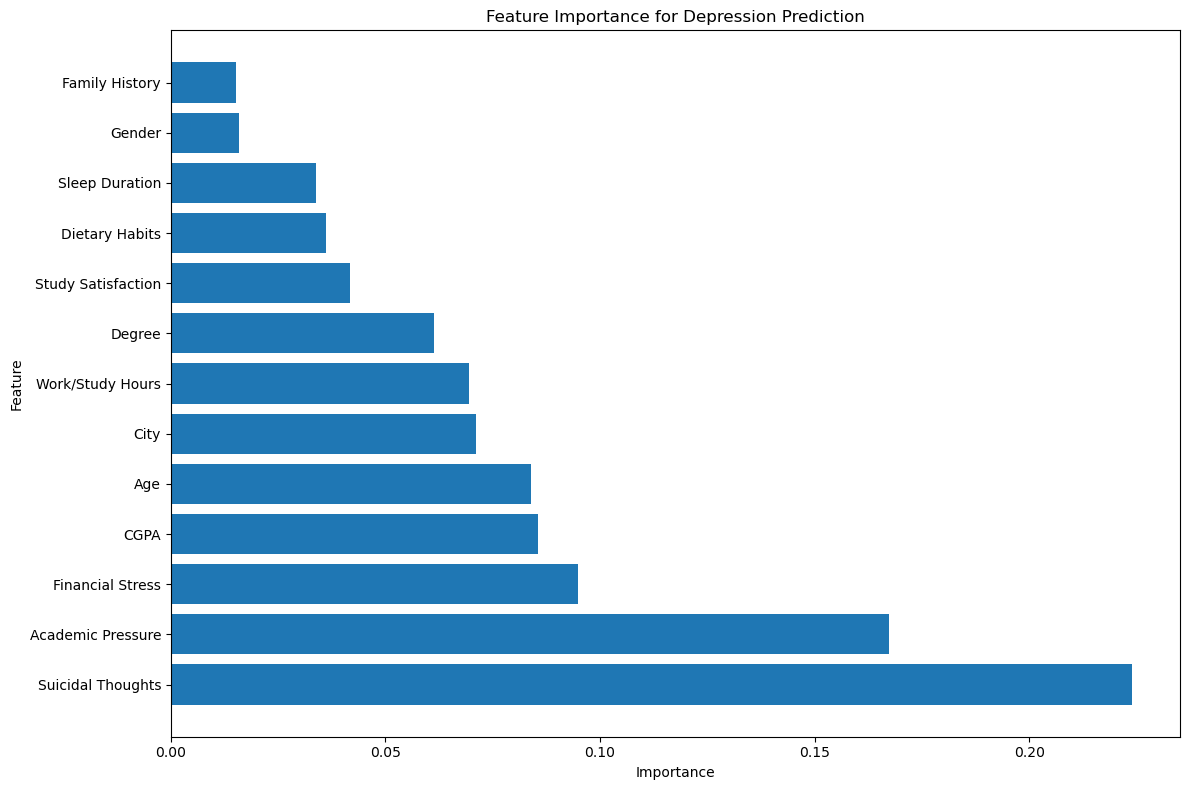

In [24]:
#plotting
plt.figure(figsize=(12, 8))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance for Depression Prediction')
plt.tight_layout()
plt.show()

In [25]:
x = df[['Age', 'Financial Stress', 'CGPA', 'Academic Pressure', 'Work/Study Hours', 'Suicidal Thoughts']]
y = df['Depression']


x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=6)

In [26]:
model = RandomForestClassifier(n_estimators=1000)
model.fit(x_train, y_train)
print(f"Random Accuracy: {model.score(x_test, y_test):.4f}")

Random Accuracy: 0.8097


In [27]:
from sklearn.utils.class_weight import compute_class_weight
from sklearn.dummy import DummyClassifier
import tensorflow as tf
from tensorflow import keras


In [28]:
#features with proven importance
x = df[['Suicidal Thoughts', 'Academic Pressure', 'Financial Stress', 'CGPA', 'Age', 'Work/Study Hours']]
y = df['Depression']

#handle missing values first
x = x.fillna(x.mean())

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=6, stratify=y
)

In [29]:
from sklearn.preprocessing import StandardScaler 

In [30]:
#NORMALIZE THE FEATURES
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [31]:
#building a model
model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    keras.layers.BatchNormalization(), #normalizes after each layer
    keras.layers.Dropout(0.3), #prevents overfitting
    keras.layers.Dense(64, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation='sigmoid')
])

#compile the model
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train) #handles imbalance
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

/Users/henok/anaconda3/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [32]:
model.compile( #specifies the optimizer, loss function, and metrics
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC()]
)

#early stopping and learning rate reduction
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=10,
    restore_best_weights=True
)
#reduces learning rate if validation loss doesn't improve
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.00001
)

In [33]:
# 8) Fit with callbacks
history = model.fit(
    x_train_scaled, y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7678 - auc: 0.8454 - loss: 0.4926 - val_accuracy: 0.8356 - val_auc: 0.9090 - val_loss: 0.4052 - learning_rate: 0.0010
Epoch 2/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8204 - auc: 0.8982 - loss: 0.4077 - val_accuracy: 0.8359 - val_auc: 0.9094 - val_loss: 0.3786 - learning_rate: 0.0010
Epoch 3/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 973us/step - accuracy: 0.8109 - auc: 0.8921 - loss: 0.4172 - val_accuracy: 0.8346 - val_auc: 0.9107 - val_loss: 0.3777 - learning_rate: 0.0010
Epoch 4/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 948us/step - accuracy: 0.8273 - auc: 0.9034 - loss: 0.3939 - val_accuracy: 0.8338 - val_auc: 0.9104 - val_loss: 0.3792 - learning_rate: 0.0010
Epoch 5/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 998us/step - accuracy: 0.8328 - auc: 0.9049 - loss: 0.3925 - val_accuracy: 0.8333 - val_auc: 0.9104 - val_loss: 0.3797 - learning_rate: 0.0010
Epoch 6/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.82

In [34]:
# 9) Evaluate
test_loss, test_acc, test_auc = model.evaluate(x_test_scaled, y_test)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test AUC: {test_auc:.4f}")

# 10) Print baseline accuracy for comparison
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(x_train, y_train)
print(f"Baseline Accuracy: {dummy.score(x_test, y_test):.4f}")

262/262 ━━━━━━━━━━━━━━━━━━━━ 0s 400us/step - accuracy: 0.8352 - auc: 0.9163 - loss: 0.3655
Test Accuracy: 0.8345
Test AUC: 0.9116
Baseline Accuracy: 0.5855


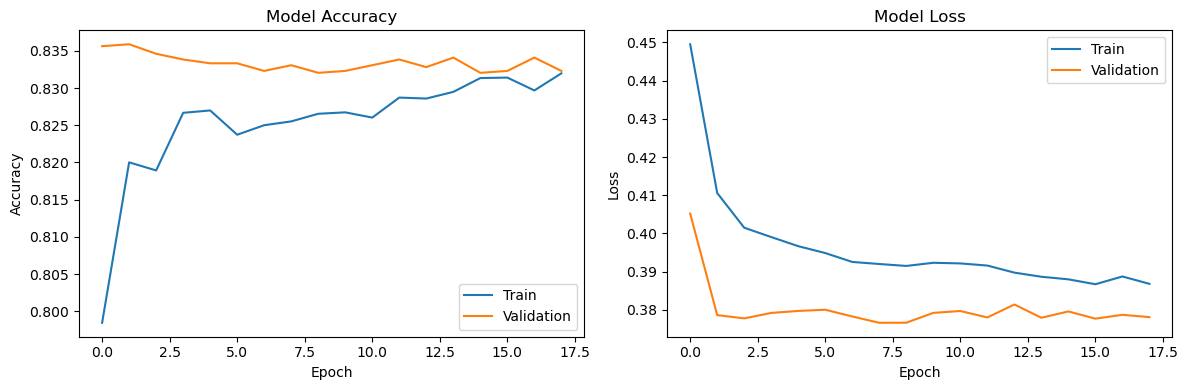

In [35]:
# 11) Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.tight_layout()
plt.show()


Dataset Source:

https://www.tensorflow.org/api_docs/python/tf/keras = tensorflow
https://keras.io/getting_started/ keras

https://www.geeksforgeeks.org/introduction-to-tensorflow/

https://www.geeksforgeeks.org/introduction-to-tensorflow/

https://www.geeksforgeeks.org/how-to-reshape-a-tensor-in-tensorflow/

https://www.geeksforgeeks.org/graphs-and-functions-in-tensorflow/

https://www.geeksforgeeks.org/implementing-neural-networks-using-tensorflow/

https://www.geeksforgeeks.org/multi-layer-perceptron-learning-in-tensorflow/

https://stackoverflow.com/questions/49332994/python-low-accuracy-with-low-loss-with-tensorflow

https://www.geeksforgeeks.org/neural-network-layers-in-tensorflow/


https://www.geeksforgeeks.org/loss-function-in-tensorflow/


https://www.geeksforgeeks.org/optimizers-in-tensorflow/


https://www.geeksforgeeks.org/tf-keras-callbacks-callback-tensorflow-callbacks/

https://www.geeksforgeeks.org/how-to-visualize-training-progress-in-tensorflow/


https://datascience.stackexchange.com/questions/93294/keras-very-low-accuracy-saturate-after-few-epochs-while-training

https://chatgpt.com/share/681241da-c4b0-800f-915e-232e34c0d3a6